<a href="https://colab.research.google.com/github/enriquefroes/treinadores-brasileirao-2026/blob/main/notebooks/03_trocas_de_treinador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_treinadores_brasileirao'
except ImportError:
    BASE = './analise_treinadores_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_por_treinador.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_por_treinador.csv'), parse_dates=['data'])
folha = pd.read_csv(os.path.join(DADOS, 'folha.csv'))

K = 10
MIN_JOGOS = 5
JOGOS_TEMPORADA = 38

MEDIA_PPJ = jogos['pontos'].mean()

def resumo(df, chaves=('clube', 'treinador')):
    g = df.groupby(list(chaves))
    r = g.agg(jogos=('pontos', 'size'), pontos=('pontos', 'sum'),
              vitorias=('pontos', lambda s: (s == 3).sum()), empates=('pontos', lambda s: (s == 1).sum()),
              derrotas=('pontos', lambda s: (s == 0).sum()), gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'),
              primeiro_jogo=('data', 'min'), ultimo_jogo=('data', 'max'), tipo=('tipo', 'first')).reset_index()
    r['ppj'] = r['pontos'] / r['jogos']
    r['aproveitamento'] = r['ppj'] / 3 * 100
    r['primeiro_jogo'] = r['primeiro_jogo'].dt.date
    r['ultimo_jogo'] = r['ultimo_jogo'].dt.date
    return r

def rotulo(r):
    return f"{r['treinador']} ({r['clube']})" + (' · interino' if r['tipo'] == 'interino' else '')

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
N = 5
trocas = []
for clube, g in jogos.sort_values('data').groupby('clube'):
    g = g.reset_index(drop=True)
    muda = g.index[g['treinador'] != g['treinador'].shift()].tolist()[1:]
    for i in muda:
        antes, depois = g.iloc[:i], g.iloc[i:]
        sai, entra = antes.iloc[-1]['treinador'], depois.iloc[0]['treinador']
        pass_antes = antes[antes['treinador'] == sai]

        prox = depois.index[depois['treinador'] != entra]
        pass_depois = depois.loc[:prox[0] - 1] if len(prox) else depois
        trocas.append({'clube': clube, 'data': depois.iloc[0]['data'].date(), 'saiu': sai, 'entrou': entra,
                       f'ppj_ultimos_{N}': antes.tail(N)['pontos'].mean(), f'ppj_primeiros_{N}': pass_depois.head(N)['pontos'].mean(),
                       'jogos_primeiros': min(N, len(pass_depois)),
                       'ppj_passagem_saiu': pass_antes['pontos'].mean(), 'ppj_passagem_entrou': pass_depois['pontos'].mean(),
                       'jogos_passagem_entrou': len(pass_depois)})
trocas = pd.DataFrame(trocas).sort_values('data').reset_index(drop=True)
trocas['variacao_curta'] = trocas[f'ppj_primeiros_{N}'] - trocas[f'ppj_ultimos_{N}']
trocas.round(2).to_csv(os.path.join(TAB, '03_trocas.csv'), index=False)
trocas.round(2)

,clube,data,saiu,entrou,ppj_ultimos_5,ppj_primeiros_5,jogos_primeiros,ppj_passagem_saiu,ppj_passagem_entrou,jogos_passagem_entrou,variacao_curta
0,Atlético-MG,2026-02-25,Jorge Sampaoli,Lucas Gonçalves,0.67,0.0,1,0.67,0.00,1,-0.67
1,Vasco,2026-02-26,Fernando Diniz,Bruno Lazaroni,0.33,0.0,1,0.33,0.00,1,-0.33
2,Atlético-MG,2026-03-11,Lucas Gonçalves,Eduardo Domínguez,0.50,1.8,5,0.00,1.65,23,1.30
3,Flamengo,2026-03-11,Filipe Luís,Leonardo Jardim,1.33,2.0,5,1.33,2.24,25,0.67
4,São Paulo,2026-03-12,Hernán Crespo,Roger Machado,2.50,1.4,5,2.50,1.27,11,-1.10
5,Remo,2026-03-12,Juan Carlos Osorio,Léo Condé,0.75,0.6,5,0.75,0.87,23,-0.15
6,Vasco,2026-03-12,Bruno Lazaroni,Renato Gaúcho,0.25,2.2,5,0.00,1.36,14,1.95
7,Cruzeiro,2026-03-18,Tite,Wesley Carvalho,0.60,0.5,2,0.50,0.50,2,-0.10
8,Santos,2026-03-22,Juan Pablo Vojvoda,Cuca,1.00,1.4,5,0.86,1.60,20,0.40
9,Botafogo,2026-03-29,Martín Anselmi,Belão,0.60,2.0,3,1.00,2.00,3,1.40


In [3]:
limiar = trocas[f'ppj_ultimos_{N}'].median()
base = []
for clube, g in jogos.sort_values('data').groupby('clube'):
    p = g['pontos'].to_numpy()
    for i in range(N, len(p) - N + 1):
        if p[i - N:i].mean() <= limiar:
            base.append(p[i:i + N].mean() - p[i - N:i].mean())
melhora_natural = np.mean(base)
comparaveis = trocas[(trocas['jogos_primeiros'] == N) & (trocas[f'ppj_ultimos_{N}'] <= limiar)]
com_troca = comparaveis['variacao_curta'].mean()
print(f'Trocas comparáveis (vindas de sequência tão ruim quanto o limiar, com {N} jogos depois): {len(comparaveis)}')
print(f'Sequências de {N} jogos com até {limiar:.2f} pontos por jogo')
print(f'  Melhora média nos {N} jogos seguintes, em QUALQUER caso:  {melhora_natural:+.2f} pontos por jogo')
print(f'  Melhora média nos {N} primeiros jogos após uma TROCA:      {com_troca:+.2f} pontos por jogo')
print(f'  Diferença atribuível à troca:                             {com_troca - melhora_natural:+.2f}')

Trocas comparáveis (vindas de sequência tão ruim quanto o limiar, com 5 jogos depois): 6
Sequências de 5 jogos com até 0.63 pontos por jogo
  Melhora média nos 5 jogos seguintes, em QUALQUER caso:  +0.74 pontos por jogo
  Melhora média nos 5 primeiros jogos após uma TROCA:      +0.97 pontos por jogo
  Diferença atribuível à troca:                             +0.24


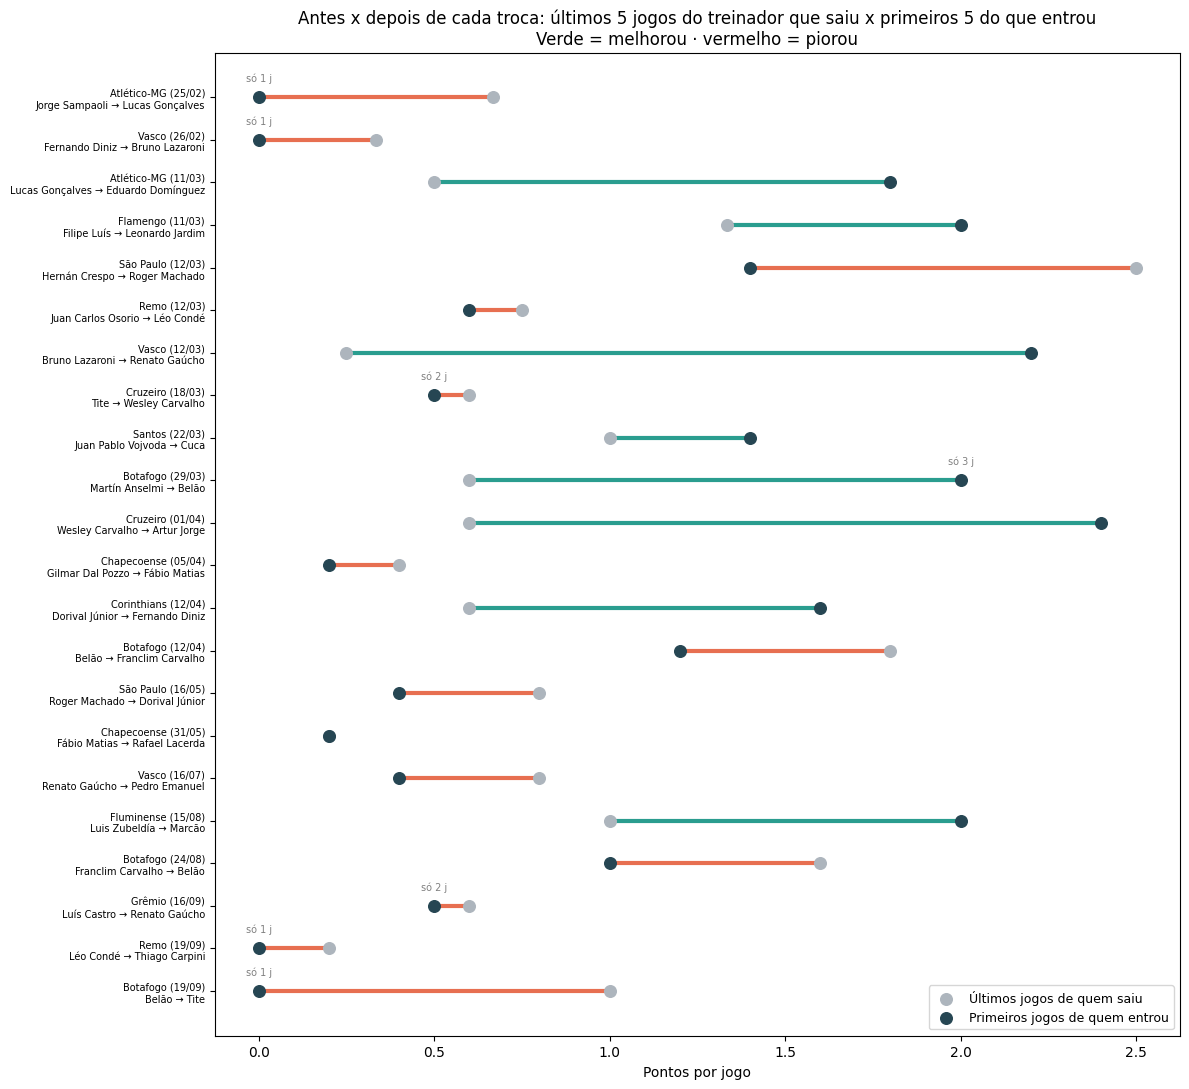

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/03a_antes_depois_trocas.png


In [4]:
t = trocas.sort_values('data', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 11))
for i, x in t.iterrows():
    a, b = x[f'ppj_ultimos_{N}'], x[f'ppj_primeiros_{N}']
    ax.plot([a, b], [i, i], color='#2a9d8f' if b > a else '#e76f51', lw=3, zorder=1)
    ax.scatter(a, i, color='#adb5bd', s=70, zorder=3, label='Últimos jogos de quem saiu' if i == 0 else None)
    ax.scatter(b, i, color='#264653', s=70, zorder=3, label='Primeiros jogos de quem entrou' if i == 0 else None)
    if x['jogos_primeiros'] < N:
        ax.text(b, i + 0.38, f"só {x['jogos_primeiros']} j", fontsize=7, ha='center', color='gray')
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f"{x['clube']} ({x['data']:%d/%m})\n{x['saiu']} → {x['entrou']}" for _, x in t.iterrows()], fontsize=7)
ax.set_xlabel('Pontos por jogo')
ax.set_title(f'Antes x depois de cada troca: últimos {N} jogos do treinador que saiu x primeiros {N} do que entrou\n'
             'Verde = melhorou · vermelho = piorou', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
salvar('03a_antes_depois_trocas.png')